#### Природа проблем (на синтетическом датасете)

Пусть у нас есть юридическое лицо $i$ и момент времени $t$. Целевая величина $Y_{it}$ -- оборот юридического лица в месяц $t$ может быть декомпозирована следующим образом:

$$
Y_{it} = A_{it} \cdot S_{it},
$$

где:

- $A_{it} \in \{0,1\}$ -- активность юридического лица, то есть факт ненулевого оборота
- $S_{it} > 0$ -- собственно оборот при условии активности.

Кажется самым логичным подходом предсказывать нашу величину как произведение двух моделей:

$$
\hat{Y}_{it} = \hat{P}(A_{it} = 1 | X_{it}) \cdot \hat{E}(S_{it}|A_{it} = 1, X_{it}),
$$

давайте попробуем реализовать подобный подход на "учебной" задаче:

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit
from scipy.stats import norm
import scipy.stats as sps

from tqdm import tqdm
from sklearn.linear_model import LogisticRegression, LinearRegression

#### Неравенство Йенсена

Если мы решили помимо декомпозиции эффектов ещё и учить модель не в оборот, а в логарифм оборота, то наша "наивная" кострукция превращается в следующее произведение:

$$
\hat{Y}_{it} = \hat{P}(A_{it} = 1 | X_{it}) \cdot  \text{e}^{\widehat{log({E}(S_{it}|A_{it} = 1, X_{it}))}} \, ,
$$

давайте посмотрим, почему такой подход оказывается неидельным:

E[exp(X)] = 1.059
exp(E[X]) = 0.940
Смещение (bias) = 0.119


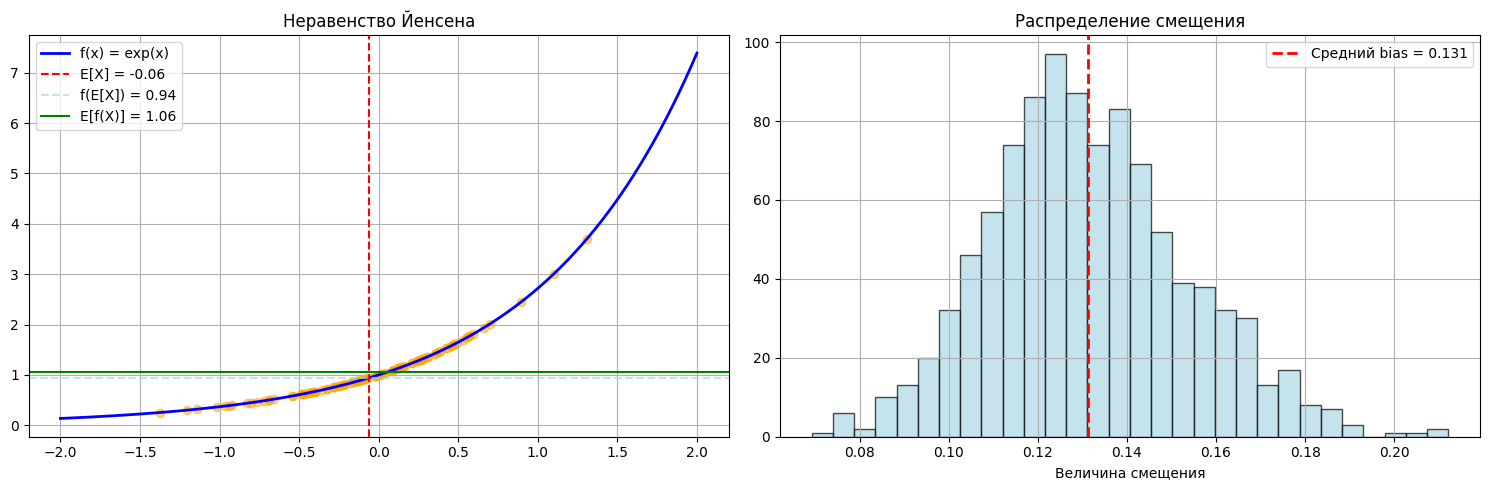

In [2]:
def demonstrate_jensen_inequality():
    import numpy as np
    import matplotlib.pyplot as plt
    
    x = np.linspace(-2, 2, 1000)
    y = np.exp(x)  # Выпуклая функция
    
    x_sample = np.random.normal(0, 0.5, 100)
    
    # E[f(X)] vs f(E[X])
    expectation_of_function = np.mean(np.exp(x_sample))
    function_of_expectation = np.exp(np.mean(x_sample))
    
    bias = expectation_of_function - function_of_expectation
    
    print(f"E[exp(X)] = {expectation_of_function:.3f}")
    print(f"exp(E[X]) = {function_of_expectation:.3f}")
    print(f"Смещение (bias) = {bias:.3f}")
    
    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График функции
    ax1.plot(x, y, 'b-', linewidth=2, label='f(x) = exp(x)')
    ax1.axvline(np.mean(x_sample), color='red', linestyle='--', 
                label=f'E[X] = {np.mean(x_sample):.2f}')
    ax1.axhline(function_of_expectation, color='lightblue', linestyle='--', alpha=0.7,
                label=f'f(E[X]) = {function_of_expectation:.2f}')
    ax1.axhline(expectation_of_function, color='green', linestyle='-', 
                label=f'E[f(X)] = {expectation_of_function:.2f}')
    ax1.scatter(x_sample, np.exp(x_sample), alpha=0.5, color='orange')
    ax1.legend()
    ax1.set_title('Неравенство Йенсена')
    ax1.grid(True)
    
    # Гистограмма смещений
    biases = []
    for _ in range(1000):
        sample = np.random.normal(0, 0.5, 100)
        bias_i = np.mean(np.exp(sample)) - np.exp(np.mean(sample))
        biases.append(bias_i)
    
    ax2.hist(biases, bins=30, alpha=0.7, color='lightblue', edgecolor='black')
    ax2.axvline(np.mean(biases), color='red', linestyle='--', linewidth=2,
                label=f'Средний bias = {np.mean(biases):.3f}')
    ax2.set_title('Распределение смещения')
    ax2.set_xlabel('Величина смещения')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

demonstrate_jensen_inequality()

то есть мы видим, что экспонента матожидания не равна матожиданию экспоненты, вследствие чего наша функция даёт систематическое "смещение".
В более общем случае это явление называется неравенством Йенсена. Мы можем утверждать, что для всякой выпуклой вниз функции $\phi(x)$ и случайной величины $X$ выполняется соотношение:
$$
\phi(E[X]) \leq E[\phi(X)].
$$
Таким образом, когда мы строим модель на логарифм целевой переменной, мы систематически занижаем предсказания.

Но давайте пока избежим сложностей, связанных с ошибками из-за нелинейностей и сосредоточимся на другой проблеме:

#### Реализуем функцию, генерирующую случайный датасет:

пусть в итоговом датасете будет:

- флаг активности ***activity***
- положительный оборот ***gmv***
- предсказания моделей ***activity_pred*** и ***gmv_act_pred***

и пусть ошибки модели будут коррелированными с коэффициентом корреляции ***correlation_coefficient***

In [3]:
def generate_norm_dist(size, x=0, y=1):
    return sps.norm.rvs(x, y, size=size)

def generate_correlating_distributions(size, correlation_coefficient):
    d1 = generate_norm_dist(size)
    d1 -= d1.mean()
    d2_ind = generate_norm_dist(size)
    d2 = correlation_coefficient * d1 + np.sqrt(1 - correlation_coefficient**2) * d2_ind
    d2 -= d2.mean()
    return(d1, d2)

def generate_sample_dataset(size, correlation_coefficient):

    d1, d2 = generate_correlating_distributions(size, correlation_coefficient)
    
    act_proba = generate_norm_dist(size, 0.5, 0.2).clip(0.01,0.99)
    act_fact = sps.bernoulli.rvs(act_proba)
    gmv = generate_norm_dist(size, 10, 4)

    # накидываем шум на финальные "предсказания" моделей, иначе эффекты нелинейности съедают нужный эффект на синтетике :(
    act_pred = (act_proba + d1/10).clip(0.01,0.99)
    gmv_act_pred = gmv + 3 * d2
    gmv_pred = gmv_act_pred * act_pred

    df = pd.DataFrame(
        {
            'index':np.arange(size),
            'active_flg':act_fact,
            'gmv':act_fact * gmv,
            'act_pred':act_pred,
            'gmv_act_pred':gmv_act_pred,
            'gmv_pred':gmv_pred
        }
    )

    return df    

In [4]:
def calc_relative_error(df, f1, f2):
    relative_error = (df[f1] - df[f2]).mean()/df[f1].mean()
    return relative_error

def calc_rel_errors_(corr_coef, size=10000):

    df = generate_sample_dataset(size,corr_coef)
    df_act = df[df.active_flg == 1]
    act_error = calc_relative_error(df, 'active_flg', 'act_pred')
    gmv_act_error = calc_relative_error(df_act, 'gmv', 'gmv_act_pred')
    gmv_error = calc_relative_error(df, 'gmv', 'gmv_pred')

    return act_error, gmv_act_error, gmv_error

def calc_rel_errors(corr_coef, size=10000):

    print('Коэффициент корреляции ошибок:', corr_coef)

    act_error, gmv_act_error, gmv_error = calc_rel_errors_(corr_coef, size)

    print(f'Activity relative error: {round(act_error * 100,2)} %')
    print(f'GMV active relative error: {round(gmv_act_error * 100,2)} %')
    print(f'GMV relative error: {round(gmv_error * 100,2)} %')

In [5]:
calc_rel_errors(0)

Коэффициент корреляции ошибок: 0
Activity relative error: -1.49 %
GMV active relative error: 0.31 %
GMV relative error: -1.05 %


In [6]:
calc_rel_errors(0.5)

Коэффициент корреляции ошибок: 0.5
Activity relative error: 0.45 %
GMV active relative error: 0.06 %
GMV relative error: -2.58 %


In [7]:
calc_rel_errors(1)

Коэффициент корреляции ошибок: 1
Activity relative error: -0.66 %
GMV active relative error: -0.15 %
GMV relative error: -6.43 %


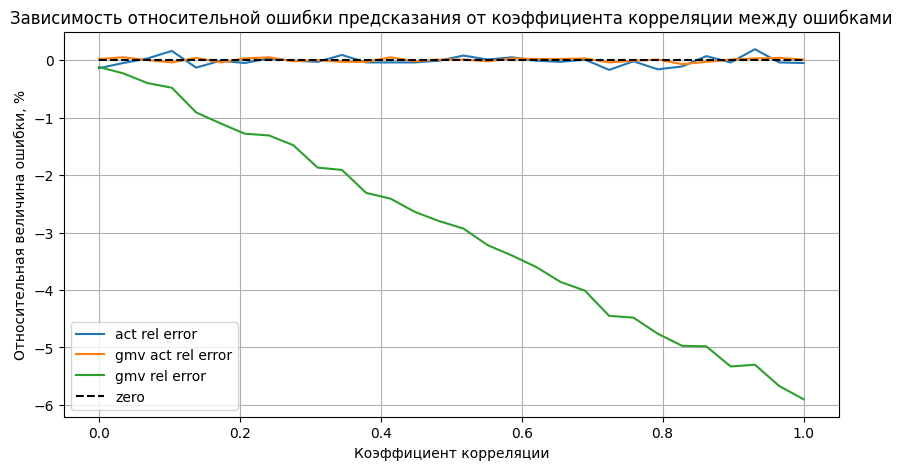

In [10]:
corrs_grid = np.linspace(0,1,30)
errors = np.zeros((3,30))

for ix, corr in enumerate(corrs_grid):
    
    errors_ = np.zeros((3,100))
    for i in range(100):
        errors_[0][i], errors_[1][i], errors_[2][i] = calc_rel_errors_(corr)
    errors[0][ix] = round(errors_[0].mean() * 100, 2)
    errors[1][ix] = round(errors_[1].mean() * 100, 2)
    errors[2][ix] = round(errors_[2].mean() * 100, 2)

plt.figure(figsize = (10,5))

plt.title('Зависимость относительной ошибки предсказания от коэффициента корреляции между ошибками')

plt.plot(corrs_grid, errors[0], label = 'act rel error')
plt.plot(corrs_grid, errors[1], label = 'gmv act rel error')
plt.plot(corrs_grid, errors[2], label = 'gmv rel error')
plt.plot(corrs_grid, [0 for _ in corrs_grid], label = 'zero', color = 'black', linestyle='dashed')
plt.grid()

plt.legend()

plt.xlabel('Коэффициент корреляции')
plt.ylabel('Относительная величина ошибки, %')

plt.show()

Можно видеть, что несмотря на то, что относительная ошибка каждой из моделей оказывается близкой к 0 и не зависящей от корреляции между ошибками, абсолютное значение ошибки произведения систематически линейно растёт с увеличением коэффициента корреляции.

То есть у нас возникает ошибка, вызванная корреляцией ошибок предсказаний. Действительно, пусть у нас есть две компоненты:
$$
\begin{array}{c}
\hat{p} = p + \varepsilon_{p}\\
\hat{s} = s + \varepsilon_{s},
\end{array} 
$$
тогда для их произведения имеем
$$
\hat{y} = \hat{p} \cdot \hat{s} = p \cdot s + p \cdot \varepsilon_{s} + s \cdot \varepsilon_{p} + \varepsilon_{s} \cdot \varepsilon_{p},
$$
даже если шум "белый" и некоррелированный с таргетом, то есть $E[p \cdot \varepsilon_{s}] = E[s \cdot \varepsilon_{p}] = 0$, остаётся член $E[\varepsilon_{s} \cdot \varepsilon_{p}]$, который в случае корреляции ошибок не равен нулю и даёт систематическое смещение:
$$
E[\hat{y}] - y = E[\varepsilon_{s} \cdot \varepsilon_{p}].
$$